In [1]:
%pip install -q -U langchain_openai langchain_core langgraph
%pip install -q langfuse
%pip install -q PyMuPDF sendgrid
!pip install sendgrid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.4/441.4 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.3/297.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.2/196.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [2]:

!pip install pytesseract
!pip install pdf2image

In [3]:
import os

import argparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from sendgrid import SendGridAPIClient
from sendgrid.helpers.mail import Mail
# import fitz  # PyMuPDF
from pdf2image import convert_from_path
import pytesseract
import re


In [22]:
import os
from google.colab import userdata

os.environ["SENDGRID_API_KEY"] = userdata.get('sendgrid')
os.environ["OPENAI_API_KEY"] = userdata.get('openai_key')
# Get keys for your project from the project settings page: https://cloud.langfuse.com

# Get keys for your project from the project settings page: https://cloud.langfuse.com
os.environ["LANGFUSE_PUBLIC_KEY"] = userdata.get('langfuse_public')
os.environ["LANGFUSE_SECRET_KEY"] = userdata.get('langfuse_secret')
#os.environ["LANGFUSE_HOST"] = "https://cloud.langfuse.com"  # 🇪🇺 EU region
os.environ["LANGFUSE_HOST"] = "https://us.cloud.langfuse.com" # 🇺🇸 US region


In [5]:
# Load environment variables
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
SENDGRID_API_KEY = os.environ.get("SENDGRID_API_KEY")

In [6]:
# Extract text from PDF using PyMuPDF
import fitz  # PyMuPDF


def extract_text_from_pdf(pdf_path:str):
    """
    Extracts text from a PDF file. If the PDF is text-based, uses PyMuPDF.
    If it’s image-based, converts it to images and applies OCR with pytesseract.

    Args:
        pdf_path (str): Path to the PDF file (e.g., "raunak_final_resume (1).pdf").

    Returns:
        str: Extracted text or an error message if extraction fails.
    """
    try:
        # Step 1: Attempt text extraction with PyMuPDF
        with fitz.open(pdf_path) as pdf:
            text = ""
            for page in pdf:
                text += page.get_text()

            # If significant text is extracted (e.g., >100 characters), assume it’s text-based
            if len(text.strip()) > 100:
                return text

        # Step 2: If little or no text is extracted, assume it’s image-based and use OCR
        images = convert_from_path(pdf_path)
        ocr_text = ""
        for image in images:
            # Perform OCR, specifying English as the language for better accuracy
            ocr_text += pytesseract.image_to_string(image, lang='eng') + "\n"

        # Step 3: Clean up the extracted text
        # Replace multiple newlines with a single newline
        ocr_text = re.sub(r'\n+', '\n', ocr_text)
        # Remove leading/trailing spaces from each line
        ocr_text = '\n'.join(line.strip() for line in ocr_text.split('\n'))

        return ocr_text

    except FileNotFoundError:
        return "Error: File not found. Please check the file path."
    except fitz.FileDataError:
        return "Error: Invalid PDF file. Please ensure the file is a valid PDF."
    except Exception as e:
        return f"An unexpected error occurred: {str(e)}"

# Keyword matching between resume and job description
def keyword_match(resume_text: str, job_description: str):
    """
    Computes similarity between resume and job description using TF-IDF.

    Args:
        resume_text (str): Text from the resume.
        job_description (str): Job description text.

    Returns:
        float: Similarity score as a percentage.
    """
    try:
        combined_text = [resume_text, job_description]
        vectorizer = TfidfVectorizer(stop_words="english")
        tfidf_matrix = vectorizer.fit_transform(combined_text)
        similarity = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])
        return similarity[0][0] * 100
    except Exception as e:
        return f"Error in keyword matching: {str(e)}"

# Grammar checking using ChatGPT
def grammar_check(resume_text: str):
    """
    Checks grammar and spelling in the resume text using ChatGPT.

    Args:
        resume_text (str): Text from the resume.

    Returns:
        str: Grammar check feedback.
    """
    try:
        llm = ChatOpenAI(model="gpt-4o", api_key=OPENAI_API_KEY)
        prompt = ChatPromptTemplate.from_template(
            "Check the following text for grammar and spelling errors and provide feedback: {text}"
        )
        response = llm.invoke(prompt.format(text=resume_text))
        return response.content
    except Exception as e:
        return f"Error in grammar check: {str(e)}"

# Formatting evaluation using ChatGPT
def format_check(resume_text: str):
    """
    Evaluates resume formatting using ChatGPT.

    Args:
        resume_text (str): Text from the resume.

    Returns:
        str: Formatting feedback.
    """
    try:
        llm = ChatOpenAI(model="gpt-4o", api_key=OPENAI_API_KEY)
        prompt = ChatPromptTemplate.from_template(
            "Evaluate the formatting of the following resume text (e.g., bullet points, layout): {text}"
        )
        response = llm.invoke(prompt.format(text=resume_text))
        return response.content
    except Exception as e:
        return f"Error in format check: {str(e)}"

# Relevance alignment with job description using ChatGPT
def relevance_check(resume_text: str, job_description: str):
    """
    Checks relevance of resume to job description using ChatGPT.

    Args:
        resume_text (str): Text from the resume.
        job_description (str): Job description text.

    Returns:
        str: Relevance feedback.
    """
    try:
        llm = ChatOpenAI(model="gpt-4o", api_key=OPENAI_API_KEY)
        prompt = ChatPromptTemplate.from_template(
            "Compare the following resume text to the job description and assess relevance: Resume: {resume}, Job Description: {job}"
        )
        response = llm.invoke(prompt.format(resume=resume_text, job=job_description))
        return response.content
    except Exception as e:
        return f"Error in relevance check: {str(e)}"

# Generate feedback report (with simple scoring)
def generate_feedback(keyword_score: float, grammar_feedback: str, format_feedback: str, relevance_feedback: str):
    """
    Generates an HTML feedback report.

    Args:
        keyword_score (float): Keyword match score.
        grammar_feedback (str): Grammar check feedback.
        format_feedback (str): Formatting feedback.
        relevance_feedback (str): Relevance feedback.

    Returns:
        str: HTML-formatted feedback report.
    """
    return f"""
    <html>
    <body>
        <h2>Resume Analysis Report</h2>
        <h3>Keyword Match Score: {keyword_score:.2f}%</h3>
        <h3>Grammar Feedback:</h3><p>{grammar_feedback}</p>
        <h3>Formatting Feedback:</h3><p>{format_feedback}</p>
        <h3>Relevance Feedback:</h3><p>{relevance_feedback}</p>
    </body>
    </html>
    """

# Send email (using SendGrid)
from sendgrid import SendGridAPIClient
from sendgrid.helpers.mail import Mail

def send_html_email(html_content: str, receiver_email: str, sender_email: str = "rauni0617@gmail.com"):
    """
    Sends an HTML email with the feedback report.

    Args:
        html_content (str): HTML content of the email.
        receiver_email (str): Recipient's email address.
        sender_email (str): Sender's email address.

    Returns:
        str: Status message.
    """
    try:
        message = Mail(
            from_email=sender_email,
            to_emails=receiver_email,
            subject="Resume Analysis Report",
            html_content=html_content
        )
        sg = SendGridAPIClient(SENDGRID_API_KEY)
        response = sg.send(message)
        return f"Email sent successfully with status code: {response.status_code}"
    except Exception as e:
        return f"Error sending email: {str(e)}"

def validate_email(email: str):
    """
    Validates an email address format.

    Args:
        email (str): Email address to validate.

    Returns:
        bool: True if valid, False otherwise.
    """
    pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
    return bool(re.match(pattern, email))

In [7]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)
tools = [extract_text_from_pdf, keyword_match, grammar_check, format_check, relevance_check, generate_feedback, send_html_email,validate_email]
# Bind tools to the LLM
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=True)


In [11]:
from typing import TypedDict, Annotated, Optional
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    input_file: str          # PDF file path for resume
    job_desc: str            # Job description text
    messages: Annotated[list[AnyMessage], add_messages]

In [12]:
from langchain_core.messages import SystemMessage

def assistant(state: AgentState):
    # Describe available tools in the system message
    tool_doc = """
extract_text_from_pdf(pdf_path: str) -> str:
    Extract all text from the PDF at the given path and return it.
keyword_match(resume_text: str, job_desc: str) -> str:
    Identify overlapping skills/keywords between the resume and job description, returning matches and a score.
grammar_check(resume_text: str) -> str:
    Check the resume text for spelling or grammar issues; return feedback.
format_check(resume_text: str) -> str:
    Evaluate resume formatting (bullet points, layout, consistency); return suggestions.
relevance_check(resume_text: str, job_desc: str) -> str:
    Compare resume to the job description and comment on alignment of skills/experience.
generate_feedback(resume_text: str, job_desc: str,
                  keyword_match: str, grammar_check: str,
                  format_check: str, relevance_check: str) -> str:
    Create a detailed HTML feedback report with scores (for keywords, grammar, formatting, relevance).
send_html_email(html_body: str, sender: str, receiver: str, subject: str) -> str:
    Send an HTML email via SendGrid and return status."""
    sys_msg = SystemMessage(content=(
        f"You are a resume analysis agent. {tool_doc} "
        f"\nThe uploaded resume file is: {state['input_file']}\n"
        f"The job description is: {state['job_desc']}\n"
        "Use the above tools to analyze the resume and provide feedback."
    ))
    # Invoke the LLM with the system message plus conversation history
    llm_output = llm_with_tools.invoke([sys_msg] + state["messages"])
    return {"messages": [llm_output], "input_file": state["input_file"], "job_desc": state["job_desc"]}


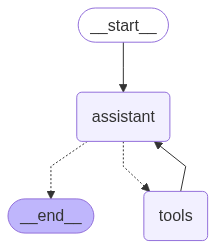

In [13]:
from langgraph.graph import StateGraph,START
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

builder = StateGraph(AgentState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "assistant")
# If the assistant calls a tool, go to tools node; otherwise, end.
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))


In [14]:
pip install fpdf2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.7/245.7 kB 11.7 MB/s eta 0:00:00


In [15]:
!wget https://noto-website-2.storage.googleapis.com/pkgs/NotoSans-unhinted.zip -O noto.zip
!unzip -o noto.zip -d noto_fonts > /dev/null


--2025-07-05 15:39:31--  https://noto-website-2.storage.googleapis.com/pkgs/NotoSans-unhinted.zip
Resolving noto-website-2.storage.googleapis.com (noto-website-2.storage.googleapis.com)... 142.250.141.207, 74.125.137.207, 142.250.101.207, ...
Connecting to noto-website-2.storage.googleapis.com (noto-website-2.storage.googleapis.com)|142.250.141.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12159212 (12M) [application/zip]
Saving to: ‘noto.zip’

noto.zip            100%[===================>]  11.60M  --.-KB/s    in 0.1s    

2025-07-05 15:39:32 (91.3 MB/s) - ‘noto.zip’ saved [12159212/12159212]



In [17]:


from fpdf import FPDF

import fitz  # PyMuPDF


def extract_text_from_pdf(pdf_path:str):
    """
    Extracts text from a PDF file. If the PDF is text-based, uses PyMuPDF.
    If it’s image-based, converts it to images and applies OCR with pytesseract.

    Args:
        pdf_path (str): Path to the PDF file (e.g., "raunak_final_resume (1).pdf").

    Returns:
        str: Extracted text or an error message if extraction fails.
    """
    try:
        # Step 1: Attempt text extraction with PyMuPDF
        with fitz.open(pdf_path) as pdf:
            text = ""
            for page in pdf:
                text += page.get_text()

            # If significant text is extracted (e.g., >100 characters), assume it’s text-based
            if len(text.strip()) > 100:
                return text

        # Step 2: If little or no text is extracted, assume it’s image-based and use OCR
        images = convert_from_path(pdf_path)
        ocr_text = ""
        for image in images:
            # Perform OCR, specifying English as the language for better accuracy
            ocr_text += pytesseract.image_to_string(image, lang='eng') + "\n"

        # Step 3: Clean up the extracted text
        # Replace multiple newlines with a single newline
        ocr_text = re.sub(r'\n+', '\n', ocr_text)
        # Remove leading/trailing spaces from each line
        ocr_text = '\n'.join(line.strip() for line in ocr_text.split('\n'))

        return ocr_text

    except FileNotFoundError:
        return "Error: File not found. Please check the file path."
    except fitz.FileDataError:
        return "Error: Invalid PDF file. Please ensure the file is a valid PDF."
    except Exception as e:
        return f"An unexpected error occurred: {str(e)}"

pdf_path = "/content/raunak_final_resume (1).pdf"
extracted_text = extract_text_from_pdf(pdf_path)


# Optional: Save the text to a file
with open("extracted_resume.txt", "w", encoding="utf-8") as f:
    f.write(extracted_text)

# (2) Define a sample job description
job_desc = (
    "We seek a Senior Software Engineer with 5+ years experience. Key skills: Python, Java, SQL, "
    "machine learning, and AWS. The candidate should have strong leadership and communication skills, "
    "and be able to work with cross-functional teams."
)

# (3) Run the agent
from langchain_core.messages import HumanMessage

initial_messages = [HumanMessage(content="Please analyze the resume and provide feedback.And send the email to the receiver informing the same")]
result_state = react_graph.invoke(
    {"messages": initial_messages, "input_file": extracted_text, "job_desc": job_desc}
)

# (4) Inspect the final messages and state
for msg in result_state["messages"]:
    print("Agent response:")
    msg.pretty_print()


Agent response:
================================ Human Message =================================

Please analyze the resume and provide feedback.And send the email to the receiver informing the same
Agent response:
================================== Ai Message ==================================
Tool Calls:
  keyword_match (call_FegDPT20xzpbBPkGCT1FGXxj)
 Call ID: call_FegDPT20xzpbBPkGCT1FGXxj
  Args:
    resume_text: Raunak Raj
Third Year Undergraduate
Civil Engg & Mathematics & Scientific Computing
Ó +91-8789595410
R raunakr22@iitk.ac.in
 raunak
¯ Raunak Raj
ACADEMIC QUALIFICATIONS
Year
Degree/Certificate
Institute
CPI/%
2022 - 2027
Double Major: ( BT-CE+BS-MTH )
Indian Institute of Technology Kanpur
8.4/10
2022
CBSE (XII)
ST.MICHAEL HIGH SCHOOL
94.2 %
2020
CBSE (X)
ST.MICHAEL HIGH SCHOOL
96.8 %
SCHOLASTIC ACHIEVEMENTS
• Qualified Joint Entrance Examination (Advanced) 2022 and secured All India Rank 5451 among 1.6 lakh candidates
• Qualified Joint Entrance Examination (Mains) 2022 an